In [16]:
#imports and libraries
!py -m pip install seaborn
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
train=pd.read_csv("../data/processed/train.csv")
val=pd.read_csv("../data/processed/val.csv")
test=pd.read_csv("../data/processed/test.csv")

xtrainScaled_smote=np.load("../data/processed/xtrain_scaled.npy")
ytrainSeverity_smote=np.load("../data/processed/ytrain_severity.npy")

FEATURES = [

    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos"
]
TARGET = "cases"

xtrainScaled=train[FEATURES].values
xvalScaled=val[FEATURES].values
xtestScaled=test[FEATURES].values
ytrain=train[TARGET].values
yval=val[TARGET].values
ytest=test[TARGET].values

In [23]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xtest,ytest):

    predictions=model.predict(xtest)
    meanSquareError=mean_squared_error(ytest, predictions)
    r2=r2_score(ytest, predictions)
    rootMeanSquareError=root_mean_squared_error(ytest, predictions)
    meanAbsoluteError=mean_absolute_error(ytest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [24]:
#Linear Regression as baseline model

linearRegression=LinearRegression()

linearRegression.fit(xtrainScaled,ytrain)

linearEvaluations=regressorEvaluation(linearRegression,xvalScaled,yval)

timecv=TimeSeriesSplit(n_splits=5)
cvScore=cross_val_score(linearRegression,xtrainScaled,ytrain,cv=timecv,scoring='r2')

print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")

jl.dump( linearRegression,"../models/linear_baseline.pkl")

The Model Performance metrics are:
R2 Score: 0.006707482290782885
Mean Squared Error: 1323.7394248583898
Root Mean Squared Error: 36.38322999485326
Mean Absolute Error: 17.77452741952651
Cross Validation Average R2 Score: 0.3304
Cross Validation R2 Scores Std: 1.0652


['../models/linear_baseline.pkl']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


data=pd.read_csv('../data/processed/train.csv')
test=pd.read_csv('../data/processed/test.csv')

x=data.drop('cases',axis=1)
x=x.drop('month',axis=1)
x=x.drop('month_num',axis=1)
x=x.drop('year',axis=1)
x=x.drop('district',axis=1)


y=data["cases"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model = RandomForestRegressor(n_estimators=200)
model.fit(x_train, y_train)
prediction=model.predict(x_test);
m=mean_squared_error(y_test,prediction)
print("root mean square:",m)
importance = model.feature_importances_

import matplotlib.pyplot as plt

plt.barh(x.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()
for col, val in zip(x.columns, importance):
    print(col, val)

root mean square: 249.61346374416794


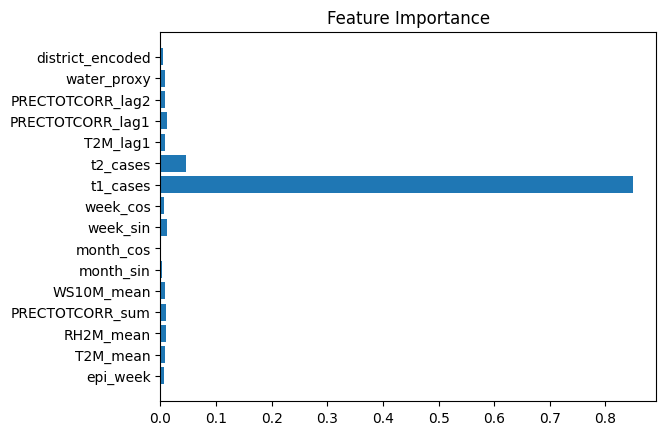

epi_week 0.005485414422544075
T2M_mean 0.007939731722203868
RH2M_mean 0.009215255672210479
PRECTOTCORR_sum 0.010719834770007626
WS10M_mean 0.008227726870021308
month_sin 0.003143664088850024
month_cos 0.0008458281399307626
week_sin 0.012037989970785262
week_cos 0.006866715461068948
t1_cases 0.8492637773126731
t2_cases 0.045776577278027634
T2M_lag1 0.008896238643486975
PRECTOTCORR_lag1 0.01168281609995451
PRECTOTCORR_lag2 0.008313399542097135
water_proxy 0.007367890372553531
district_encoded 0.004217139633584697


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


data=pd.read_csv('../data/processed/train.csv')
test=pd.read_csv('../data/processed/test.csv')

x=data.drop('cases',axis=1)
x=x.drop('month',axis=1)
x=x.drop('month_num',axis=1)
x=x.drop('year',axis=1)
x=x.drop('district',axis=1)
x=x.drop("deaths",axis=1)

a=test.drop('cases',axis=1)
a=a.drop('month',axis=1)
a=a.drop('month_num',axis=1)
a=a.drop('year',axis=1)
a=a.drop('district',axis=1)
a=a.drop("deaths",axis=1)

y=data["cases"]
b=test["cases"]


model = RandomForestRegressor(n_estimators=200)
model.fit(x, y)
prediction=model.predict(a);
m=mean_squared_error(b,prediction)
print("root mean square:",m)
importance = model.feature_importances_

import matplotlib.pyplot as plt

plt.barh(x.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()
for col, val in zip(x.columns, importance):
    print(col, val)

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # metrics
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    # print summary
    print("📊 MODEL EVALUATION SUMMARY")
    print("-" * 40)

    print("🔹 TRAIN SET")
    print(f"MSE : {train_mse:.4f}")
    print(f"RMSE: {train_rmse:.4f}")
    print(f"MAE : {train_mae:.4f}")
    print(f"R2  : {train_r2:.4f}")

    print("\n🔹 TEST SET")
    print(f"MSE : {test_mse:.4f}")
    print(f"RMSE: {test_rmse:.4f}")
    print(f"MAE : {test_mae:.4f}")
    print(f"R2  : {test_r2:.4f}")

    print("\n🔍 OVERFITTING CHECK")
    if train_r2 - test_r2 > 0.1:
        print("⚠️ Possible overfitting detected")
    else:
        print("✅ No major overfitting detected")